In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shubh0799/churn-modelling/Churn_Modelling.csv


## Bank Customer Churn Prediction

### Objective:

The goal of this notebook is to predict whether a customer will leave the bank (Churn) based on their credit score, age, balance, and other factors.

### Key Steps:

Data Cleaning and Preprocessing

Encoding Categorical Features

Standardizing Numerical Features

Training a Random Forest Classifier

Analyzing Feature Importance

## Import Libraries and Load Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# List files to find the correct path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load the dataset
# Adjust the path below based on the output of the print statement above
df = pd.read_csv('/kaggle/input/datasets/shubh0799/churn-modelling/Churn_Modelling.csv')
df.head()

/kaggle/input/datasets/shubh0799/churn-modelling/Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1. Data Cleaning & Feature Selection

In this step, we drop columns that provide no predictive value, such as names and IDs. We also check for any missing values that might disrupt the model training.

In [4]:
# Check for missing values
print("Missing values count:\n", df.isnull().sum())

# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Summary statistics for a quick overview
df.describe()

Missing values count:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 2. Categorical Encoding

Machine learning models require numerical input. We will use Label Encoding for Gender (Binary) and One-Hot Encoding for Geography (Multi-category).

In [5]:
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for Geography
# We use drop_first=True to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("Columns after encoding:", df.columns.tolist())
df.head()

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


### 3. Data Splitting & Scaling

To evaluate our model fairly, we split the data into Training (80%) and Testing (20%) sets. We also scale the features because variables like Balance and Age have very different magnitudes.

In [6]:
# Split features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing complete. Training set size:", X_train.shape)

Preprocessing complete. Training set size: (8000, 11)


## 4. Model Training: Random Forest

We will use a Random Forest Classifier. It is an ensemble method that combines multiple decision trees to improve accuracy and prevent overfitting.

In [7]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

## 5. Model Evaluation

Model Accuracy: 86.65%



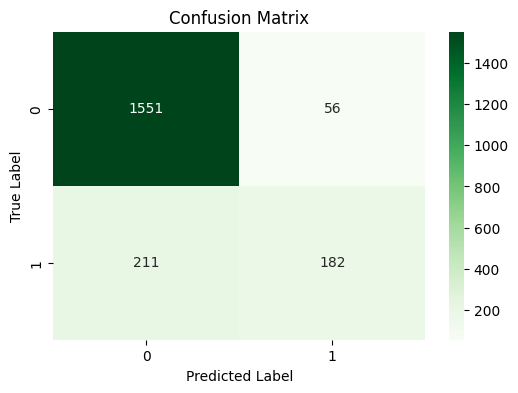

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [8]:
# Print Accuracy
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Detailed Report
print("Classification Report:\n", classification_report(y_test, y_pred))

## 6. Feature Importance

Understanding which features contribute most to the prediction is vital for business decisions. Below, we visualize the impact of each variable on customer churn.

/tmp/ipykernel_57/3719480770.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


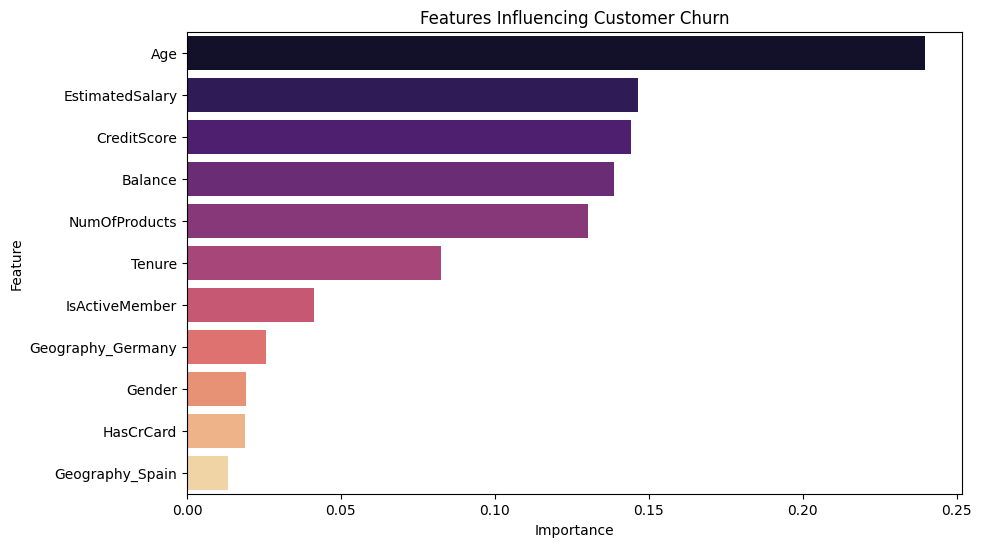

In [9]:
# Calculate importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Features Influencing Customer Churn')
plt.show()

## 7. Final Conclusion & Business Insights

### Model Performance Summary

The Random Forest Classifier achieved an overall accuracy of 86.65%. While this is a strong baseline, the classification report reveals a common challenge in churn prediction:

#### Precision for Churners (Class 1): 
At 0.76, when the model predicts a customer will leave, it is correct about 76% of the time.

#### Recall for Churners (Class 1): 
At 0.46, the model currently only identifies 46% of the total customers who actually churned.

#### The Takeaway: 
The model is "conservative." It doesn't cry wolf often, but it misses a significant portion of customers who are at risk of leaving. In a real banking scenario, we might want to tune the model to increase Recall, even if it means more false positives, to ensure we capture more at-risk clients.

### Key Drivers of Churn
According to the Feature Importance analysis, the top 3 factors influencing a customer's decision to leave are:

#### Age: 
By far the most significant predictor. This suggests that certain age demographics may feel the bank's products no longer meet their life-stage needs.

#### Estimated Salary & Credit Score: 
Financial stability and profile play a massive role in retention.

#### Balance: 
High-balance customers might be more sensitive to interest rates or premium services offered by competitors.

### Recommendations for the Bank

#### Targeted Retention: 
Focus loyalty programs or "re-engagement" campaigns on the older demographic, as they show the highest propensity to churn.

#### Product Optimization: 
Since NumOfProducts is a high-ranking feature, the bank should investigate if customers with only one product feel "unattached" and if cross-selling could increase "stickiness."

#### Model Iteration: 
To improve the Recall of churners, future versions of this notebook could explore:

#### SMOTE (Synthetic Minority Over-sampling Technique) to handle the class imbalance.

XGBoost or LightGBM for potentially higher predictive power.

Hyperparameter Tuning using GridSearchCV to optimize the Random Forest forest depth and leaf size.